# NB02 - Doppler audio extraction

This notebook explores Doppler ultrasound audio recordings extracted from AVI files.

The goal is to inspect the audio streams, extract Doppler audio, visualize the waveform, detect candidate cardiac cycles, and compute preliminary audio-derived features.

The same two candidate recordings used in NB01 are analyzed.

In [1]:
import json, subprocess
import numpy as np
import soundfile as sf
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter, hilbert, welch, spectrogram, find_peaks
from scipy.ndimage import uniform_filter1d
from pathlib import Path

In [2]:
# Candidate recordings used for audio exploration.
# Use the same two AVI files that were used in NB01 image-based validation.
video_path_a = r"D:\code\DopplerLab\ultrasound_recordings\candidate.avi"
video_path_b = r"D:\code\DopplerLab\ultrasound_recordings\candidate_b.avi"
CANDIDATE_A_PATH = Path(video_path_a)
CANDIDATE_B_PATH = Path(video_path_b)

candidate_paths = {
    "candidate_a": CANDIDATE_A_PATH,
    "candidate_b": CANDIDATE_B_PATH,
}

for name, path in candidate_paths.items():
    print(f"{name}: {path}")
    print(f"  exists: {path.exists()}")

candidate_a: D:\code\DopplerLab\ultrasound_recordings\candidate.avi
  exists: True
candidate_b: D:\code\DopplerLab\ultrasound_recordings\candidate_b.avi
  exists: True


## Media stream inspection

Before extracting audio, the AVI files are inspected to determine:

- whether an audio stream exists,
- audio codec,
- sample rate,
- channel count,
- audio duration.

This step verifies that Doppler audio is available and can be extracted reliably.

In [3]:
def inspect_media_streams(video_path):
    """
    Inspect video and audio stream properties before Doppler processing.
    """
    cmd = [
        "ffprobe",
        "-v",
        "quiet",
        "-print_format",
        "json",
        "-show_format",
        "-show_streams",
        str(video_path),
    ]

    result = subprocess.run(cmd, capture_output=True, text=True, check=True,)

    metadata = json.loads(result.stdout)
    print("=" * 80)
    print(video_path)
    print("=" * 80)
    streams = metadata.get("streams", [])

    for stream in streams:
        codec_type = stream.get("codec_type")
        print()
        print(f"Stream type: {codec_type}")

        if codec_type == "audio":
            print(f"Codec: {stream.get('codec_name')}")
            print(f"Sample rate: {stream.get('sample_rate')}")
            print(f"Channels: {stream.get('channels')}")
            print(f"Duration: {stream.get('duration')}")

        elif codec_type == "video":
            print(f"Codec: {stream.get('codec_name')}")
            print(f"Resolution: {stream.get('width')} x {stream.get('height')}")
            print(f"FPS: {stream.get('r_frame_rate')}")

    return metadata

In [4]:
meta_a = inspect_media_streams(CANDIDATE_A_PATH)
print()
meta_b = inspect_media_streams(CANDIDATE_B_PATH)

D:\code\DopplerLab\ultrasound_recordings\candidate.avi

Stream type: video
Codec: msmpeg4v3
Resolution: 720 x 540
FPS: 30/1

Stream type: audio
Codec: aac
Sample rate: 96000
Channels: 2
Duration: 6.112000

D:\code\DopplerLab\ultrasound_recordings\candidate_b.avi

Stream type: video
Codec: msmpeg4v3
Resolution: 720 x 540
FPS: 30/1

Stream type: audio
Codec: aac
Sample rate: 96000
Channels: 2
Duration: 5.738667


## Audio extraction to WAV

The Doppler audio stream is extracted from each AVI file into a WAV file.

The audio is converted to mono PCM WAV to simplify downstream signal processing.  
This avoids handling stereo channels separately during the first exploratory stage.

In [5]:
def extract_audio_to_wav(
    video_path,
    output_dir,
    output_name=None,
    sample_rate=None,
    mono=True,
    overwrite=True,
):
    """
    Extract a Doppler audio stream into a WAV file for downstream analysis.
    """

    video_path = Path(video_path)
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    if output_name is None:
        output_name = video_path.stem + "_audio.wav"

    output_path = output_dir / output_name
    cmd = ["ffmpeg"]

    if overwrite:
        cmd.append("-y")
    else:
        cmd.append("-n")

    cmd.extend(["-i", str(video_path), "-vn", "-acodec", "pcm_s16le"])

    if mono:
        cmd.extend(["-ac", "1"])

    if sample_rate is not None:
        cmd.extend(["-ar", str(sample_rate)])

    cmd.append(str(output_path))
    result = subprocess.run(cmd, capture_output=True, text=True)

    if result.returncode != 0:
        print(result.stderr)
        raise RuntimeError("Audio extraction failed.")

    print(f"Extracted audio:")
    print(f"input: {video_path}")
    print(f"output: {output_path}")

    return output_path

In [6]:
AUDIO_OUT_DIR = Path("audio_exports")
AUDIO_OUT_DIR.mkdir(exist_ok=True)

audio_paths = {}

for name, video_path in candidate_paths.items():
    audio_paths[name] = extract_audio_to_wav(
        video_path=video_path,
        output_dir=AUDIO_OUT_DIR,
        output_name=f"{name}_audio.wav",
        sample_rate=None,
        mono=True,
        overwrite=True,
    )

audio_paths

Extracted audio:
input: D:\code\DopplerLab\ultrasound_recordings\candidate.avi
output: audio_exports\candidate_a_audio.wav
Extracted audio:
input: D:\code\DopplerLab\ultrasound_recordings\candidate_b.avi
output: audio_exports\candidate_b_audio.wav


{'candidate_a': WindowsPath('audio_exports/candidate_a_audio.wav'),
 'candidate_b': WindowsPath('audio_exports/candidate_b_audio.wav')}

## Audio loading and waveform inspection

The extracted WAV files are loaded into Python.

This section inspects:

- sample rate,
- duration,
- waveform amplitude,
- signal dynamic range.

The goal is to understand the raw Doppler audio signal before any filtering or beat detection.

In [7]:
def load_audio(audio_path):
    """
    Load a Doppler audio recording and summarize its basic properties.
    """

    signal, sample_rate = sf.read(audio_path)
    duration_s = len(signal) / sample_rate

    info = {
        "signal": signal.astype(np.float64),
        "sample_rate": sample_rate,
        "duration_s": duration_s,
        "n_samples": len(signal),
    }

    print("=" * 80)
    print(audio_path)
    print("=" * 80)
    print(f"Sample rate : {sample_rate:,} Hz")
    print(f"Duration : {duration_s:.3f} s")
    print(f"Samples : {len(signal):,}")
    print()
    print(f"Min value : {signal.min():.4f}")
    print(f"Max value : {signal.max():.4f}")
    print(f"Mean : {signal.mean():.6f}")
    print(f"Std : {signal.std():.6f}")

    return info

In [8]:
audio_data = {}
for name, path in audio_paths.items():
    audio_data[name] = load_audio(path)

audio_exports\candidate_a_audio.wav
Sample rate : 96,000 Hz
Duration : 6.112 s
Samples : 586,752

Min value : -0.1720
Max value : 0.1692
Mean : 0.000001
Std : 0.044343
audio_exports\candidate_b_audio.wav
Sample rate : 96,000 Hz
Duration : 5.739 s
Samples : 550,912

Min value : -0.1688
Max value : 0.1885
Mean : 0.000001
Std : 0.036548


In [9]:
def plot_audio_waveform(signal, sample_rate, title="Audio waveform"):
    """
    Plot raw audio waveform.
    """
    t = np.arange(len(signal)) / sample_rate
    plt.figure(figsize=(14, 4))
    plt.plot(t, signal, linewidth=0.5)
    plt.xlabel("Time [s]")
    plt.ylabel("Amplitude")
    plt.title(title)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

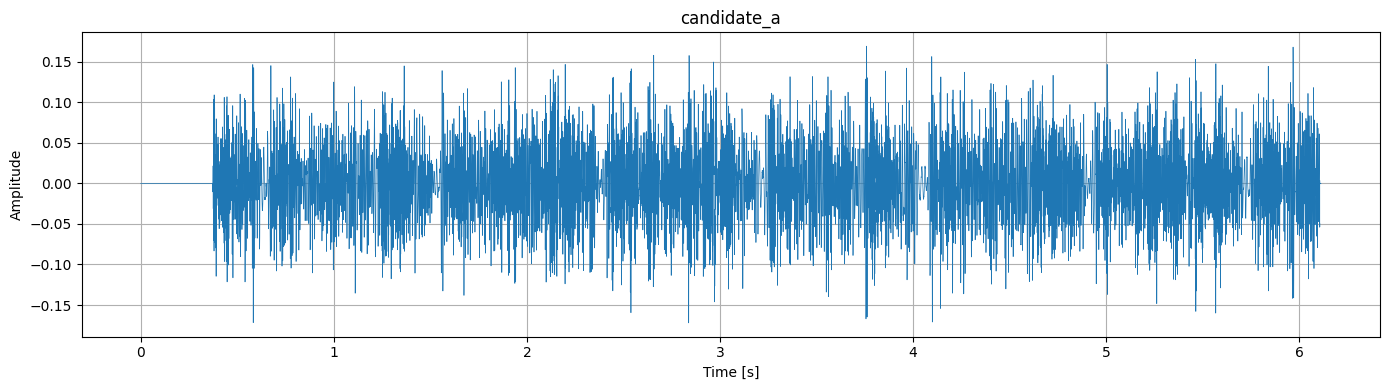

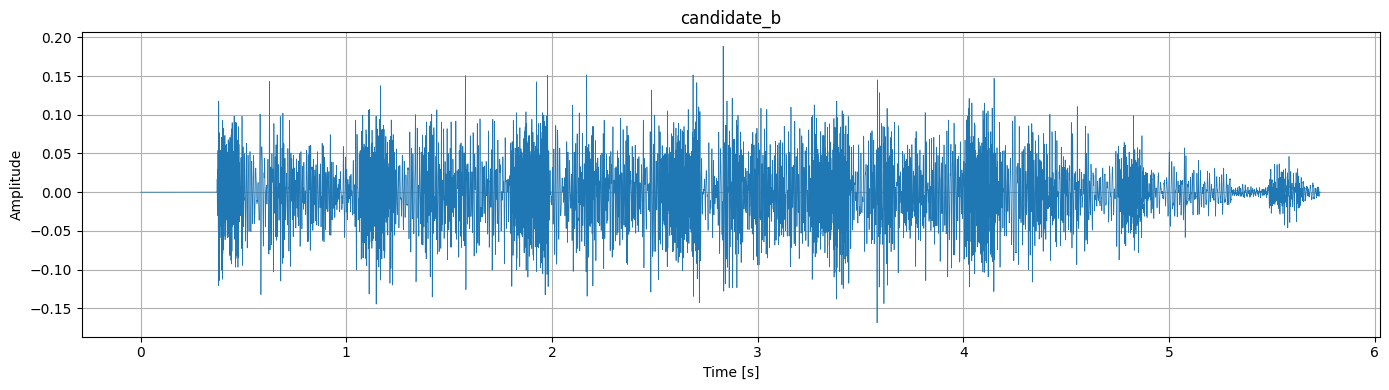

In [10]:
for name, data in audio_data.items():
    plot_audio_waveform(data["signal"], data["sample_rate"], title=name)

In [11]:
def compute_audio_envelope(signal, sample_rate, window_ms=20, smooth_ms=100):
    """
    Extract the Doppler audio amplitude envelope for waveform analysis.
    """
    signal = np.asarray(signal, dtype=np.float64)
    rms_window = max(1, int(sample_rate * window_ms / 1000))
    power = signal ** 2
    envelope = np.sqrt(np.convolve(power, np.ones(rms_window) / rms_window, mode="same"))
    smooth_window = int(sample_rate * smooth_ms / 1000)
    if smooth_window % 2 == 0:
        smooth_window += 1
    if smooth_window >= 5:
        envelope = savgol_filter(envelope, smooth_window, polyorder=2)

    t = np.arange(len(signal)) / sample_rate

    return t, envelope

In [12]:
def plot_audio_envelope(t, envelope, title="Audio envelope"):
    """
    Plot audio amplitude envelope.
    """

    plt.figure(figsize=(14, 4))
    plt.plot(t, envelope, linewidth=2)
    plt.xlabel("Time [s]")
    plt.ylabel("Envelope amplitude")
    plt.title(title)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

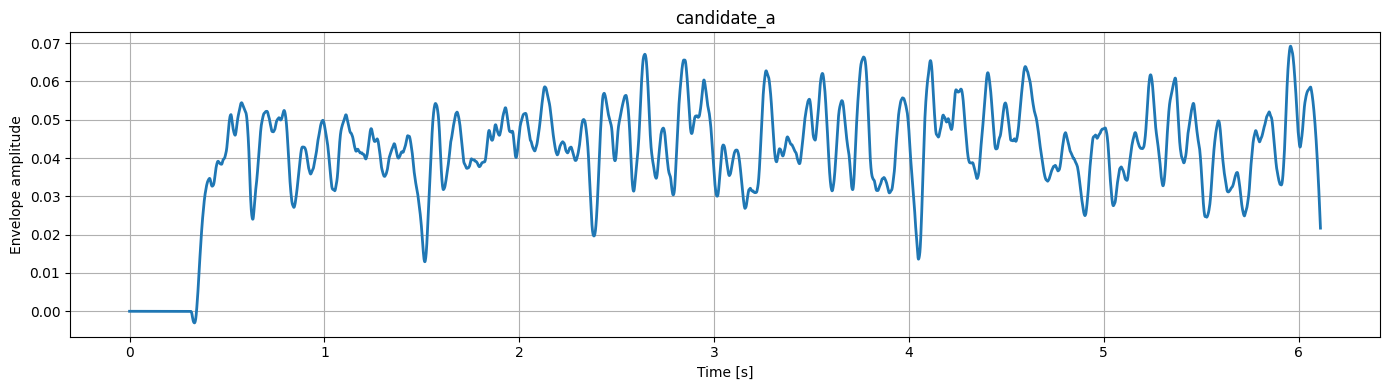

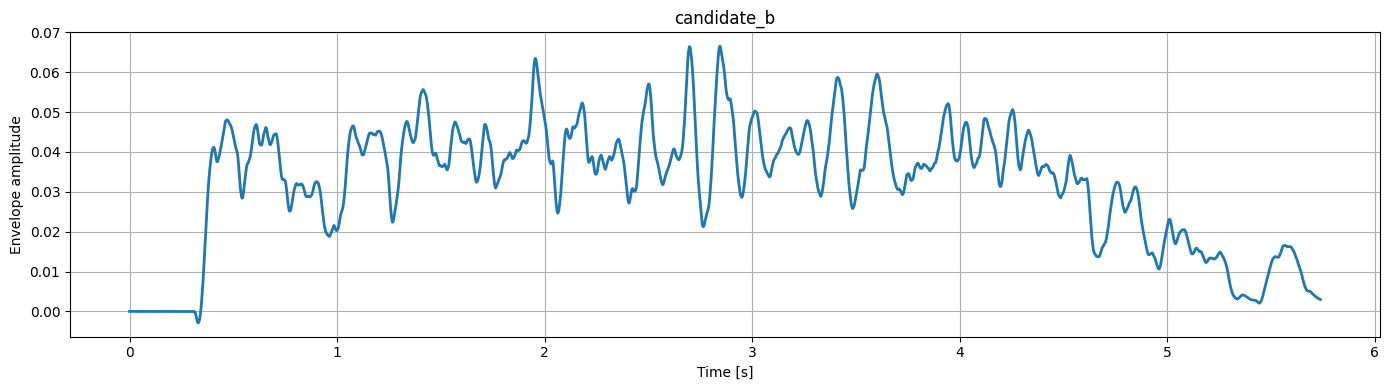

In [13]:
audio_envelopes = {}

for name, data in audio_data.items():
    t, envelope = compute_audio_envelope(data["signal"], data["sample_rate"])

    audio_envelopes[name] = {"t": t, "envelope": envelope}
    plot_audio_envelope(t, envelope, title=name)

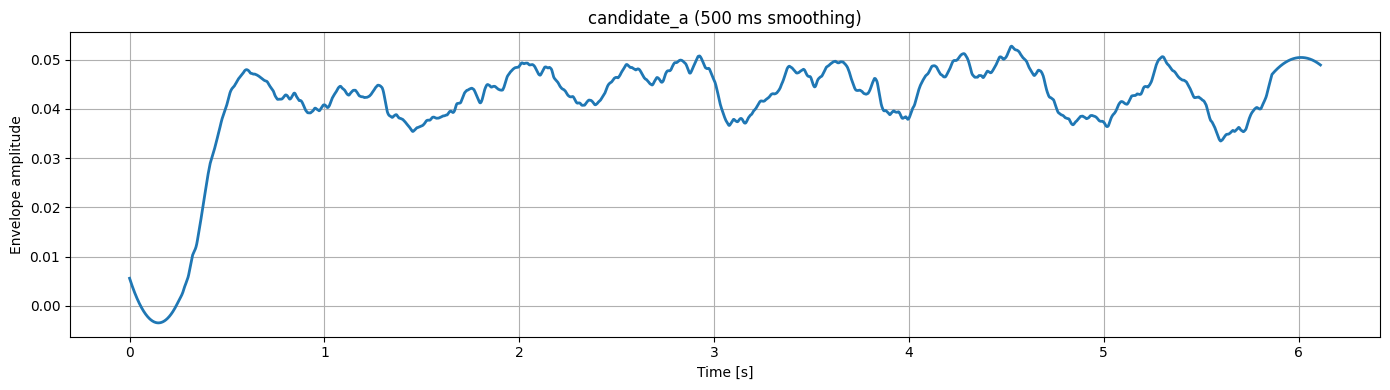

In [ ]:
for name, data in audio_data.items():
    t, envelope = compute_audio_envelope(data["signal"], data["sample_rate"], window_ms=20, smooth_ms=500)
    plot_audio_envelope(t, envelope, title=f"{name} (500 ms smoothing)")

## Local audio waveform inspection

The global waveform view compresses hundreds of thousands of samples into a single plot.

Short time windows are inspected to understand the local Doppler audio structure and determine whether cardiac cycle-related patterns are visible in the raw signal.

In [ ]:
def plot_audio_zoom(signal, sample_rate, start_s=1.0, duration_s=1.0, title="Audio zoom"):
    """
    Visualize a short segment of the raw Doppler audio waveform.
    """
    signal = np.asarray(signal)
    start_idx = int(start_s * sample_rate)
    end_idx = int((start_s + duration_s) * sample_rate)
    start_idx = max(0, start_idx)
    end_idx = min(len(signal), end_idx)
    segment = signal[start_idx:end_idx]
    t = np.arange(start_idx, end_idx) / sample_rate
    plt.figure(figsize=(14, 4))
    plt.plot(t, segment, linewidth=0.6)
    plt.xlabel("Time [s]")
    plt.ylabel("Amplitude")
    plt.title(title)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [ ]:
for name, data in audio_data.items():
    plot_audio_zoom(signal=data["signal"], sample_rate=data["sample_rate"], start_s=1.0, 
                    duration_s=1.0, title=f"{name} - raw audio zoom 1.0-2.0 s")

## Hilbert envelope

The Hilbert transform is used to estimate the instantaneous amplitude of the Doppler audio signal.

Compared with RMS energy estimation, the Hilbert envelope often provides a cleaner representation of signal amplitude fluctuations and may reveal cardiac-cycle-related patterns more clearly.

The resulting envelope is smoothed and compared with the RMS envelope from the previous section.

In [ ]:
def compute_hilbert_envelope(signal, sample_rate, smooth_ms=200):
    """
    Extract an alternative Doppler audio envelope for waveform analysis.
    """
    signal = np.asarray(signal, dtype=np.float64)
    analytic_signal = hilbert(signal)
    envelope = np.abs(analytic_signal)
    smooth_window = int(sample_rate * smooth_ms / 1000)
    if smooth_window % 2 == 0:
        smooth_window += 1
    if smooth_window >= 5:
        envelope = savgol_filter(envelope, smooth_window, polyorder=2)
    t = np.arange(len(signal)) / sample_rate

    return t, envelope

In [ ]:
hilbert_results = {}
for name, data in audio_data.items():
    t, envelope = compute_hilbert_envelope(signal=data["signal"], sample_rate=data["sample_rate"], smooth_ms=200)
    hilbert_results[name] = {"t": t, "envelope": envelope}
    plot_audio_envelope(t, envelope, title=f"{name} - Hilbert envelope")

In [ ]:
def plot_envelope_comparison(t_rms, rms_env, t_hilbert, hilbert_env, title="Envelope comparison"):
    """
    Visualize RMS and Hilbert Doppler audio envelopes.
    """
    plt.figure(figsize=(14, 4))
    plt.plot(t_rms, rms_env, label="RMS", linewidth=2)
    plt.plot(t_hilbert, hilbert_env, label="Hilbert", linewidth=2)
    plt.xlabel("Time [s]")
    plt.ylabel("Amplitude")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [ ]:
for name in audio_data.keys():
    plot_envelope_comparison(
        audio_envelopes[name]["t"],
        audio_envelopes[name]["envelope"],
        hilbert_results[name]["t"],
        hilbert_results[name]["envelope"],
        title=name,
    )

## Frequency spectrum inspection

The Doppler audio waveform is transformed into the frequency domain.

This analysis helps identify dominant frequency components and determines whether cardiac-cycle-related modulation may be present in specific frequency bands.

The frequency spectrum is explored before any beat detection is attempted.

In [ ]:
def plot_audio_spectrum(signal, sample_rate, title="Audio spectrum"):
    """
    Visualize the frequency content of a Doppler audio recording.
    """
    freqs, psd = welch(signal, fs=sample_rate, nperseg=8192)
    plt.figure(figsize=(12, 4))
    plt.semilogy(freqs, psd, linewidth=2)
    plt.xlabel("Frequency [Hz]")
    plt.ylabel("PSD")
    plt.title(title)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return freqs, psd

In [ ]:
spectra = {}

for name, data in audio_data.items():
    freqs, psd = plot_audio_spectrum(data["signal"], data["sample_rate"], title=name)
    spectra[name] = {"freqs": freqs, "psd": psd}

## Spectrogram inspection

The Doppler audio signal is visualized as a spectrogram.

Unlike waveform plots, the spectrogram shows how frequency content changes over time and may reveal cardiac-cycle-related modulation patterns that are not visible in amplitude-only representations.

This visualization is used to identify whether pulsatile flow produces recurring frequency structures.

In [ ]:
def plot_audio_spectrogram(signal, sample_rate, max_freq=5000, title="Audio spectrogram"):
    """
    Visualize a Doppler audio spectrogram.
    """

    freqs, times, Sxx = spectrogram(signal, fs=sample_rate, nperseg=2048, noverlap=1536, scaling="density")
    mask = freqs <= max_freq
    plt.figure(figsize=(14, 5))
    plt.pcolormesh(times, freqs[mask], 10 * np.log10(Sxx[mask] + 1e-12), shading="gouraud")
    plt.colorbar(label="Power [dB]")
    plt.xlabel("Time [s]")
    plt.ylabel("Frequency [Hz]")
    plt.title(title)
    plt.tight_layout()
    plt.show()

    return freqs, times, Sxx

In [ ]:
spectrograms = {}

for name, data in audio_data.items():
    freqs, times, Sxx = plot_audio_spectrogram(
        signal=data["signal"],
        sample_rate=data["sample_rate"],
        max_freq=5000,
        title=name,
    )
    spectrograms[name] = {
        "freqs": freqs,
        "times": times,
        "Sxx": Sxx,
    }

## Spectrogram-based Doppler energy signal

The spectrogram showed recurring Doppler energy bursts that may correspond to cardiac cycles.

To convert the spectrogram into a one-dimensional signal, power is summed across a selected Doppler frequency band.

This produces a time series representing Doppler audio energy over time, which can later be used for candidate beat detection.

In [ ]:
def compute_spectrogram_band_energy(freqs, times, Sxx, fmin=100, fmax=2000, smooth_points=9, normalize=True):
    """
    Compute a band-limited Doppler energy signal from a spectrogram.
    """

    freqs = np.asarray(freqs)
    times = np.asarray(times)
    Sxx = np.asarray(Sxx)
    band_mask = (freqs >= fmin) & (freqs <= fmax)
    energy = np.sum(Sxx[band_mask, :], axis=0)
    energy = np.asarray(energy, dtype=np.float64)

    if smooth_points is not None and smooth_points >= 5:
        if smooth_points % 2 == 0:
            smooth_points += 1
        if smooth_points < len(energy):
            energy = savgol_filter(energy, window_length=smooth_points, polyorder=2)

    if normalize:
        energy_min = np.nanmin(energy)
        energy_max = np.nanmax(energy)

        if energy_max > energy_min:
            energy = (energy - energy_min) / (energy_max - energy_min)

    return times, energy

In [ ]:
def plot_spectrogram_band_energy(times, energy, title="Spectrogram band energy"):
    """
    Visualize the Doppler band-energy signal over time.
    """
    plt.figure(figsize=(14, 4))
    plt.plot(times, energy, linewidth=2)
    plt.xlabel("Time [s]")
    plt.ylabel("Normalized band energy")
    plt.title(title)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [ ]:
band_energy_results = {}
for name, spec in spectrograms.items():
    times, energy = compute_spectrogram_band_energy(
        freqs=spec["freqs"],
        times=spec["times"],
        Sxx=spec["Sxx"],
        fmin=100,
        fmax=2000,
        smooth_points=9,
        normalize=True,
    )

    band_energy_results[name] = {"times": times, "energy": energy}
    plot_spectrogram_band_energy(times, energy, title=f"{name} - spectrogram band energy 100-2000 Hz")

In [ ]:
for name, spec in spectrograms.items():
    times, energy = compute_spectrogram_band_energy(
        freqs=spec["freqs"],
        times=spec["times"],
        Sxx=spec["Sxx"],
        fmin=100,
        fmax=2000,
        smooth_points=31,
        normalize=True,
    )
    plot_spectrogram_band_energy(times, energy, title=f"{name} - smoothed band energy")

## Spectral centroid analysis

The spectral centroid represents the center of mass of the frequency spectrum at each time point.

Instead of measuring total Doppler energy, the centroid tracks where the energy is located within the frequency range.

This may reveal pulsatile frequency shifts associated with cardiac cycles more clearly than amplitude-based measures.

In [ ]:
def compute_spectral_centroid(freqs, times, Sxx, fmin=100, fmax=3000, smooth_points=15):
    """
    Extract the dominant Doppler frequency trajectory from the spectrogram.
    """

    freqs = np.asarray(freqs)
    times = np.asarray(times)
    Sxx = np.asarray(Sxx)
    mask = (freqs >= fmin) & (freqs <= fmax)

    band_freqs = freqs[mask]
    band_power = Sxx[mask]

    numerator = np.sum(band_freqs[:, None] * band_power, axis=0)
    denominator = np.sum(band_power, axis=0)
    centroid = numerator / (denominator + 1e-12)
    
    if smooth_points is not None and smooth_points >= 5:
        if smooth_points % 2 == 0:
            smooth_points += 1
        if smooth_points < len(centroid):
            centroid = savgol_filter(centroid, window_length=smooth_points, polyorder=2)

    return times, centroid

In [ ]:
def plot_spectral_centroid(times, centroid, title="Spectral centroid"):
    """
    Visualize the Doppler spectral-centroid trajectory over time.
    """
    plt.figure(figsize=(14, 4))
    plt.plot(times, centroid, linewidth=2)
    plt.xlabel("Time [s]")
    plt.ylabel("Centroid [Hz]")
    plt.title(title)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [ ]:
centroid_results = {}

for name, spec in spectrograms.items():
    times, centroid = compute_spectral_centroid(
        freqs=spec["freqs"],
        times=spec["times"],
        Sxx=spec["Sxx"],
        fmin=100,
        fmax=3000,
        smooth_points=15,
    )
    centroid_results[name] = {"times": times, "centroid": centroid}
    plot_spectral_centroid(times, centroid, title=f"{name} - spectral centroid")

## Audio beat candidate detection

Candidate cardiac cycles are detected from the spectral centroid signal.

The goal of this stage is exploratory.

Detected peaks represent candidate Doppler audio beats and are not yet synchronized with image-derived waveform peaks.


In [ ]:
def detect_audio_beats(times, centroid, min_distance_s=0.5, prominence=100):
    """
    Detect candidate Doppler audio beats from the spectral-centroid signal.
    """
    dt = np.median(np.diff(times))
    distance = max(1, int(min_distance_s / dt))
    peak_idx, props = find_peaks(centroid, distance=distance, prominence=prominence)
    peak_times = times[peak_idx]
    peak_values = centroid[peak_idx]
    print(f"Detected beats: {len(peak_idx)}")

    if len(peak_times) > 1:
        rr = np.diff(peak_times)
        print(f"Mean RR: {rr.mean():.3f} s")
        print(f"Estimated HR: {60 / rr.mean():.1f} bpm")

    return peak_idx, peak_times, peak_values

In [ ]:
def plot_audio_beats(times, centroid, peak_times, peak_values, title="Audio beat detection"):
    """
    Visualize detected Doppler audio beats on the spectral-centroid signal.
    """
    plt.figure(figsize=(14, 4))
    plt.plot(times, centroid, linewidth=2)
    plt.scatter(peak_times, peak_values, s=80)
    plt.xlabel("Time [s]")
    plt.ylabel("Centroid [Hz]")
    plt.title(title)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [ ]:
audio_beats = {}
for name, result in centroid_results.items():
    peak_idx, peak_times, peak_values = detect_audio_beats(
        times=result["times"],
        centroid=result["centroid"],
        min_distance_s=0.5,
        prominence=100,
    )
    audio_beats[name] = {
        "peak_idx": peak_idx,
        "peak_times": peak_times,
        "peak_values": peak_values,
    }
    plot_audio_beats(
        result["times"],
        result["centroid"],
        peak_times,
        peak_values,
        title=name,
    )

## Reusable audio processing pipeline

The exploratory analysis identified a stable audio processing workflow:

1. Load WAV audio.
2. Compute a spectrogram.
3. Compute the spectral centroid trajectory.
4. Detect candidate cardiac cycles from centroid peaks.
5. Compute recording-level summary features.

The goal of this section is to wrap the current workflow into reusable functions that can be applied to multiple Doppler recordings.

In [ ]:
def summarize_audio_beats(beat_df, recording_duration_s=None):
    """
    Summarize Doppler audio beats after beat-level quality control.
    """

    beat_df = beat_df.copy()
    valid_df = beat_df[beat_df["is_valid"]].copy()
    summary = {}
    summary["n_detected_beats"] = len(beat_df)
    summary["n_valid_beats"] = len(valid_df)

    if len(beat_df) > 0:
        summary["valid_beat_fraction"] = (len(valid_df) / len(beat_df))
    else:
        summary["valid_beat_fraction"] = np.nan

    if len(valid_df) >= 2:
        rr = valid_df["beat_time_s"].diff().dropna()
        summary["mean_rr_s"] = rr.mean()
        summary["std_rr_s"] = rr.std(ddof=0)
        summary["mean_hr_bpm"] = 60.0 / rr.mean()
    else:
        summary["mean_rr_s"] = np.nan
        summary["std_rr_s"] = np.nan
        summary["mean_hr_bpm"] = np.nan

    if len(valid_df) > 0:
        summary["mean_centroid_hz"] = (valid_df["peak_centroid_hz"].mean())
        summary["max_centroid_hz"] = (valid_df["peak_centroid_hz"].max())
        summary["min_centroid_hz"] = (valid_df["peak_centroid_hz"].min())
    else:
        summary["mean_centroid_hz"] = np.nan
        summary["max_centroid_hz"] = np.nan
        summary["min_centroid_hz"] = np.nan
        
    summary["recording_duration_s"] = recording_duration_s

    if len(valid_df) > 0:
        summary["usable_duration_s"] = (valid_df["beat_time_s"].max()- valid_df["beat_time_s"].min())
    else:
        summary["usable_duration_s"] = np.nan

    if (recording_duration_s is not None and recording_duration_s > 0 and not np.isnan(summary["usable_duration_s"])):
        summary["usable_fraction"] = (summary["usable_duration_s"] / recording_duration_s)
    else:
        summary["usable_fraction"] = np.nan

    return pd.DataFrame([summary])

## Audio beat quality control

Not all detected audio beats have the same signal quality.

A simple quality-control rule is applied using peak spectral centroid values.

Beats with substantially lower centroid values than the recording median are flagged as low quality.

In [ ]:
def apply_audio_qc(beat_df, centroid_fraction=0.60):
    """
    Flag low-quality Doppler audio beats using spectral-centroid thresholds.
    """
    beat_df = beat_df.copy()
    median_centroid = np.median(beat_df["peak_centroid_hz"])
    threshold = (centroid_fraction * median_centroid)
    beat_df["median_centroid_hz"] = median_centroid
    beat_df["qc_threshold_hz"] = threshold
    beat_df["is_valid"] = (beat_df["peak_centroid_hz"] >= threshold)

    return beat_df

## Single-recording audio processing pipeline

This section wraps the complete Doppler audio processing workflow into a single function.

A single Doppler recording is processed through the following stages:

- audio loading,
- spectrogram computation,
- spectral centroid extraction,
- audio beat detection,
- beat-level feature extraction,
- recording-level feature aggregation.

The function returns:

- `result` - intermediate outputs used for diagnostics,
- `beat_df` - beat-level audio features,
- `summary_df` - aggregated recording-level features.

This wrapper provides a standardized interface for future audio-image synchronization and multimodal Doppler analysis.

In [ ]:
def build_audio_beat_table(peak_times, peak_values):
    """
    Build beat-level Doppler audio features from detected beat candidates.
    """
    peak_times = np.asarray(peak_times)
    peak_values = np.asarray(peak_values)
    rows = []

    for i in range(len(peak_times)):
        row = {}
        row["beat_id"] = i + 1
        row["beat_time_s"] = peak_times[i]
        row["peak_centroid_hz"] = peak_values[i]

        if i > 0:
            row["rr_interval_s"] = ( peak_times[i] - peak_times[i - 1])
        else:
            row["rr_interval_s"] = np.nan

        rows.append(row)

    return pd.DataFrame(rows)

In [ ]:
def process_audio_recording(audio_path, centroid_fmin=100, centroid_fmax=3000, centroid_smooth_points=15, 
                            min_distance_s=0.5, prominence=100, qc_centroid_fraction=0.60):
    """
    Run the initial Doppler audio pipeline with beat-level centroid QC.
    
    Returns diagnostic outputs, beat-level audio features, and recording-level summaries.
    """

    audio = load_audio(audio_path)
    signal = audio["signal"]
    sample_rate = audio["sample_rate"]

    freqs, times, Sxx = spectrogram(signal, fs=sample_rate, nperseg=2048, noverlap=1536, scaling="density")

    centroid_times, centroid = compute_spectral_centroid(freqs=freqs, times=times, Sxx=Sxx, fmin=centroid_fmin, fmax=centroid_fmax, 
                                                         smooth_points=centroid_smooth_points)
    (peak_idx, peak_times, peak_values) = detect_audio_beats(times=centroid_times, centroid=centroid, min_distance_s=min_distance_s, 
                                                             prominence=prominence)
    beat_df = build_audio_beat_table(peak_times=peak_times, peak_values=peak_values)
    beat_df = apply_audio_qc(beat_df=beat_df, centroid_fraction=qc_centroid_fraction)
    summary_df = summarize_audio_beats(beat_df=beat_df, recording_duration_s=audio["duration_s"])
    result = {
        "audio_path": audio_path,
        "signal": signal,
        "sample_rate": sample_rate,
        "freqs": freqs,
        "spectrogram_times": times,
        "Sxx": Sxx,
        "centroid_times": centroid_times,
        "centroid": centroid,
        "peak_idx": peak_idx,
        "peak_times": peak_times,
        "peak_values": peak_values,
    }

    return result, beat_df, summary_df

In [ ]:
audio_pipeline_results = {}
for name, audio_path in audio_paths.items():
    print()
    print("=" * 80)
    print(name)
    print("=" * 80)
    result, beat_df, summary_df = process_audio_recording(audio_path=audio_path)
    audio_pipeline_results[name] = {"result": result, "beat_df": beat_df, "summary_df": summary_df}
    print()
    print("Beat-level features with QC")
    display(beat_df)
    print()
    print("Recording-level summary from valid beats")
    display(summary_df)

## Validation on longer Doppler recordings

The initial audio pipeline was developed on short candidate recordings.

Longer Doppler recordings are now inspected to evaluate whether the same pipeline generalizes to longer clips and whether signal-quality degradation can be detected.

One recording, `candidate_long_quality_test`, contains a known operator-observed probe displacement and signal loss after approximately 25-30 seconds. This recording is used as a quality-gate validation case.

In [ ]:
RECORDINGS_DIR = Path(r"D:\code\DopplerLab\ultrasound_recordings")

new_candidate_paths = {
    "candidate_long_quality_test": RECORDINGS_DIR / "candidate_long_quality_test.avi",
    "candidate_avi_1": RECORDINGS_DIR / "candidate_1.avi",
    "candidate_avi_2": RECORDINGS_DIR / "candidate_2.avi",
    "candidate_avi_3": RECORDINGS_DIR / "candidate_3.avi",
}

for name, path in new_candidate_paths.items():
    print(name, path, path.exists())

### Media inspection for longer recordings

The new candidate recordings are inspected before audio extraction.

This verifies video resolution, frame rate, audio codec, sample rate, channel count, and duration.

In [ ]:
for name, path in new_candidate_paths.items():
    print("\n", "=" * 80)
    print(name)
    inspect_media_streams(path)

### Long-recording audio pipeline test

The long candidate recording is processed with the existing audio pipeline.

This test checks whether spectral-centroid beat detection works on a longer recording and whether beat-level QC alone is sufficient to detect known signal degradation.

In [ ]:
long_audio_path = extract_audio_to_wav(
    video_path=new_candidate_paths["candidate_long_quality_test"],
    output_dir=AUDIO_OUT_DIR,
    output_name="candidate_long_quality_test_audio.wav",
    sample_rate=None,
    mono=True,
    overwrite=True,
)
long_result, long_beat_df, long_summary_df = process_audio_recording(audio_path=long_audio_path)
display(long_beat_df)
display(long_summary_df)

## Audio quality gate validation

The initial audio pipeline detected cardiac cycles using spectral centroid peaks.

However, a longer recording demonstrated that beat-level centroid quality control alone is not sufficient to detect global Doppler signal loss.

This section uses a long recording with known operator-observed probe displacement to validate an additional segment-level quality gate based on spectrogram band energy.

## Long-recording spectrogram inspection

The purpose of this section is to inspect spectrogram stability over a long Doppler recording.

The recording contains a period of high-quality Doppler signal followed by gradual probe displacement and signal degradation.

The goal is to determine whether spectrogram energy decreases during signal loss and whether additional quality-control metrics should be added to the audio pipeline.

In [ ]:
plot_audio_spectrogram(signal=long_result["signal"], sample_rate=long_result["sample_rate"], title="candidate_long_quality_test")

## Long-recording Doppler energy inspection

The purpose of this section is to investigate whether Doppler signal degradation is associated with a decrease in spectrogram band energy.

A long recording containing both a high-quality Doppler segment and a signal-loss segment is used as a quality-control benchmark.

The hypothesis is that spectrogram band energy should decrease substantially after probe displacement and Doppler signal loss.

In [ ]:
def compute_band_energy(
    signal,
    sample_rate,
    fmin=100,
    fmax=2000,
    smooth_points=25,
    normalize=True,
    lower_percentile=5,
    upper_percentile=95,
):
    """
    Compute a spectrogram-based Doppler energy signal for segment-level quality control.
    """

    freqs, times, Sxx = spectrogram(signal, fs=sample_rate, nperseg=2048, noverlap=1536, scaling="density")
    freq_mask = ((freqs >= fmin) & (freqs <= fmax))
    band_energy = np.sum(Sxx[freq_mask], axis=0)
    band_energy = np.asarray(band_energy, dtype=np.float64)

    if smooth_points is not None and smooth_points > 1:
        band_energy = uniform_filter1d(band_energy, size=smooth_points)

    if normalize:
        low = np.percentile(band_energy, lower_percentile)
        high = np.percentile(band_energy, upper_percentile)

        if high > low:
            band_energy = ((band_energy - low) / (high - low))
            band_energy = np.clip(band_energy, 0, 1)

    return times, band_energy

In [ ]:
energy_times, band_energy = compute_band_energy(
    signal=long_result["signal"],
    sample_rate=long_result["sample_rate"],
    fmin=100,
    fmax=2000,
    smooth_points=25,
    normalize=True,
    lower_percentile=5,
    upper_percentile=95,
)

plot_spectrogram_band_energy(energy_times, band_energy, title="candidate_long_quality_test - robust band energy")

In [ ]:
def detect_usable_audio_segment(times, band_energy, energy_threshold=0.20):
    """
    Detect usable Doppler recording segments for segment-level quality control.
    """
    mask = band_energy >= energy_threshold
    if not np.any(mask):

        return {
            "usable_start_s": np.nan,
            "usable_end_s": np.nan,
            "usable_duration_s": 0.0,
            "usable_fraction": 0.0,
            "energy_threshold": energy_threshold,
        }

    usable_idx = np.where(mask)[0]
    start_idx = usable_idx[0]
    end_idx = usable_idx[-1]

    usable_start_s = float(times[start_idx])
    usable_end_s = float(times[end_idx])

    usable_duration_s = (usable_end_s - usable_start_s)
    recording_duration_s = float(times[-1])
    usable_fraction = (usable_duration_s / recording_duration_s)

    return {
        "usable_start_s": usable_start_s,
        "usable_end_s": usable_end_s,
        "usable_duration_s": usable_duration_s,
        "usable_fraction": usable_fraction,
        "energy_threshold": energy_threshold,
    }

In [ ]:
def plot_band_energy_with_threshold(times, band_energy, threshold, title):
    """
    Visualize Doppler band energy and segment-level QC threshold.
    """

    plt.figure(figsize=(14, 4))
    plt.plot(times, band_energy, linewidth=2, label="Band energy")
    plt.axhline(threshold, linestyle="--", linewidth=2, label=f"Threshold={threshold}")
    plt.xlabel("Time [s]")
    plt.ylabel("Normalized band energy")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.show()

In [ ]:
segment_info = detect_usable_audio_segment(times=energy_times, band_energy=band_energy, energy_threshold=0.20)
print(segment_info)
plot_band_energy_with_threshold(times=energy_times, band_energy=band_energy, threshold=0.20, title="candidate_long_quality_test - QC threshold")

## Final audio processing pipeline with segment-level QC

Long-recording validation showed that beat-level spectral-centroid QC alone is not sufficient to detect Doppler signal loss.

The final audio pipeline therefore combines:

- beat-level QC based on spectral centroid,
- segment-level QC based on robust spectrogram band energy.

This wrapper represents the finalized audio-processing entry point for future Doppler fusion experiments.

In [ ]:
def process_audio_recording_with_qc(
    audio_path,
    centroid_fmin=100,
    centroid_fmax=3000,
    centroid_smooth_points=15,
    min_distance_s=0.5,
    prominence=100,
    qc_centroid_fraction=0.80,
    energy_fmin=100,
    energy_fmax=2000,
    energy_smooth_points=25,
    energy_threshold=0.20,
):
    """
    Run the finalized Doppler audio pipeline with beat-level and segment-level QC.
    
    Returns diagnostic outputs, beat-level features, and recording-level summaries
    for downstream image-audio fusion.
    """

    audio = load_audio(audio_path)
    signal = audio["signal"]
    sample_rate = audio["sample_rate"]
    recording_duration_s = audio["duration_s"]

    freqs, times, Sxx = spectrogram(signal, fs=sample_rate, nperseg=2048, noverlap=1536, scaling="density")
    centroid_times, centroid = compute_spectral_centroid(freqs=freqs, times=times, Sxx=Sxx, fmin=centroid_fmin, fmax=centroid_fmax, 
                                                         smooth_points=centroid_smooth_points)

    peak_idx, peak_times, peak_values = detect_audio_beats(times=centroid_times, centroid=centroid, min_distance_s=min_distance_s, 
                                                           prominence=prominence)
    beat_df = build_audio_beat_table(peak_times=peak_times, peak_values=peak_values)
    beat_df = apply_audio_qc(beat_df=beat_df, centroid_fraction=qc_centroid_fraction)

    beat_df = beat_df.rename(columns={"is_valid": "is_valid_centroid",})
    energy_times, band_energy = compute_band_energy(
        signal=signal,
        sample_rate=sample_rate,
        fmin=energy_fmin,
        fmax=energy_fmax,
        smooth_points=energy_smooth_points,
        normalize=True,
        lower_percentile=5,
        upper_percentile=95,
    )
    usable_segment = detect_usable_audio_segment(times=energy_times, band_energy=band_energy, energy_threshold=energy_threshold)
    usable_start_s = usable_segment["usable_start_s"]
    usable_end_s = usable_segment["usable_end_s"]

    beat_df["is_inside_usable_segment"] = ((beat_df["beat_time_s"] >= usable_start_s) & (beat_df["beat_time_s"] <= usable_end_s))
    beat_df["is_valid_final"] = (beat_df["is_valid_centroid"] & beat_df["is_inside_usable_segment"])
    beat_df["is_consecutive_final_valid"] = (beat_df["is_valid_final"] & beat_df["is_valid_final"].shift(1).fillna(False))
    final_valid_df = beat_df[beat_df["is_valid_final"]].copy()
    rr_valid = beat_df.loc[beat_df["is_consecutive_final_valid"],"rr_interval_s"].dropna()

    summary = {}
    summary["n_detected_beats"] = len(beat_df)
    summary["n_centroid_valid_beats"] = int(beat_df["is_valid_centroid"].sum())
    summary["n_final_valid_beats"] = int(beat_df["is_valid_final"].sum())
    summary["n_consecutive_final_rr"] = len(rr_valid)

    if len(beat_df) > 0:
        summary["centroid_valid_fraction"] = (summary["n_centroid_valid_beats"] / len(beat_df))
        summary["final_valid_fraction"] = (summary["n_final_valid_beats"] / len(beat_df))
    else:
        summary["centroid_valid_fraction"] = np.nan
        summary["final_valid_fraction"] = np.nan
    if len(rr_valid) > 0:
        summary["mean_rr_s"] = rr_valid.mean()
        summary["std_rr_s"] = rr_valid.std(ddof=0)
        summary["mean_hr_bpm"] = 60.0 / rr_valid.mean()
    else:
        summary["mean_rr_s"] = np.nan
        summary["std_rr_s"] = np.nan
        summary["mean_hr_bpm"] = np.nan
    if len(final_valid_df) > 0:
        summary["mean_centroid_hz"] = (final_valid_df["peak_centroid_hz"].mean())
        summary["max_centroid_hz"] = (final_valid_df["peak_centroid_hz"].max())
        summary["min_centroid_hz"] = (final_valid_df["peak_centroid_hz"].min())
    else:
        summary["mean_centroid_hz"] = np.nan
        summary["max_centroid_hz"] = np.nan
        summary["min_centroid_hz"] = np.nan
    summary["recording_duration_s"] = recording_duration_s
    summary["usable_start_s"] = usable_start_s
    summary["usable_end_s"] = usable_end_s
    summary["segment_usable_duration_s"] = (usable_segment["usable_duration_s"])

    summary["segment_usable_fraction"] = (usable_segment["usable_fraction"])
    summary["energy_threshold"] = (usable_segment["energy_threshold"])
    summary["qc_centroid_fraction"] = qc_centroid_fraction
    summary_df = pd.DataFrame([summary])

    result = {
        "audio_path": audio_path,
        "signal": signal,
        "sample_rate": sample_rate,
        "freqs": freqs,
        "spectrogram_times": times,
        "Sxx": Sxx,
        "centroid_times": centroid_times,
        "centroid": centroid,
        "peak_idx": peak_idx,
        "peak_times": peak_times,
        "peak_values": peak_values,
        "band_energy_times": energy_times,
        "band_energy": band_energy,
        "usable_segment": usable_segment,
    }

    return result, beat_df, summary_df

In [ ]:
long_result_v2, long_beat_df_v2, long_summary_df_v2 = process_audio_recording_with_qc(audio_path=long_audio_path)
display(long_beat_df_v2[long_beat_df_v2["is_valid_final"]])
display(long_summary_df_v2)
plot_band_energy_with_threshold(
    times=long_result_v2["band_energy_times"],
    band_energy=long_result_v2["band_energy"],
    threshold=long_summary_df_v2.loc[0, "energy_threshold"],
    title="candidate_long_quality_test - final audio QC",
)

## NB02 conclusions

This notebook demonstrated that Doppler ultrasound audio contains usable physiological information.

Audio streams were successfully extracted from AVI recordings and converted to WAV format.

Spectrogram analysis showed recurring Doppler energy bursts consistent with cardiac cycles. Spectral centroid trajectories provided a useful signal for audio beat candidate detection.

The first beat-level audio pipeline produced:

- detected audio beats,
- RR intervals,
- estimated heart rate,
- peak spectral centroid values,
- centroid-based beat-level quality control.

A longer Doppler recording was then used as a quality-gate validation case. The operator observed probe displacement and signal loss after approximately 25-30 seconds. Spectrogram inspection confirmed this degradation.

The initial long-recording test showed that centroid-based beat QC alone was not sufficient, because all 98 detected beats passed QC despite known signal loss.

A robust band-energy signal was computed from the spectrogram. Using an energy threshold of 0.20, the usable Doppler segment was automatically detected as approximately 0.59-27.27 seconds.

This showed that centroid-based beat quality control is not sufficient on its own for long recordings. A segment-level energy gate is needed to identify usable Doppler audio regions and reject signal-loss periods.

The finalized NB02 audio approach therefore contains two complementary quality-control levels:

- beat-level QC based on spectral centroid,
- segment-level QC based on robust spectrogram band energy.
